# Load data

In [9]:
import pandas as pd

root_dir = '/Users/cmontefusco/Documents/DSAI2/9. Azure/Data/'
source = root_dir+'bronze/new/'

flow = pd.read_csv(source+'flow_schwartau.csv', parse_dates=['timestamp'])
humidity = pd.read_csv(source+'humidity_schwartau.csv', parse_dates=['timestamp'])
temperature = pd.read_csv(source+'temperature_schwartau.csv', parse_dates=['timestamp'])
weight = pd.read_csv(source+'weight_schwartau.csv', parse_dates=['timestamp'])


In [11]:
flow.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2513836 entries, 0 to 2513835
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   timestamp  2513836 non-null  datetime64[ns]
 1   flow       2513836 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 38.4 MB


In [13]:
humidity.info() # some missing values for humidity

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  1761 non-null   datetime64[ns]
 1   humidity   1749 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 27.6 KB


In [15]:
temperature.info() # some missing temp values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253430 entries, 0 to 253429
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   timestamp    253430 non-null  datetime64[ns]
 1   temperature  251398 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.9 MB


In [17]:
weight.info() # some missing weight values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  1761 non-null   datetime64[ns]
 1   weight     1749 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 27.6 KB


# Flow

In [19]:
flow.head(15)
# (flow['timestamp'].max()-flow['timestamp'].min())*24/2
(flow['timestamp'] - flow['timestamp'].shift(1)).value_counts()

timestamp
0 days 00:01:00        2513704
0 days 00:02:00            112
0 days 01:01:00              6
-1 days +23:01:00            4
5 days 09:32:00              2
0 days 11:56:00              2
0 days 02:44:00              2
1 days 01:19:00              2
-880 days +00:00:00          1
Name: count, dtype: int64

In [21]:
flow.sort_values(by='timestamp').head(20)

,timestamp,flow
0,2017-01-01 14:15:00,0
1256918,2017-01-01 14:15:00,0
1256919,2017-01-01 14:16:00,0
1,2017-01-01 14:16:00,0
2,2017-01-01 14:17:00,0
1256920,2017-01-01 14:17:00,0
3,2017-01-01 14:18:00,0
1256921,2017-01-01 14:18:00,0
4,2017-01-01 14:19:00,0
1256922,2017-01-01 14:19:00,0


In [23]:
flow.loc[:flow.shape[0]/2-1, 'flow'].agg(['min', 'max'])
flow.loc[flow.shape[0]/2:, 'flow'].agg(['min', 'max'])

min       0
max    7999
Name: flow, dtype: int64

In [25]:
departures = flow.loc[:flow.shape[0]/2-1].copy()
arrivals = flow.loc[flow.shape[0]/2:].copy()

In [27]:
departures.duplicated().sum()
departures.loc[departures.duplicated(), 'timestamp'].dt.date.value_counts()
departures.loc[departures.duplicated(), 'timestamp'].dt.day_name().unique()
departures.loc[departures.duplicated(), 'timestamp'].dt.hour.unique()

# fulfills all expectations of time change

array([2], dtype=int32)

In [29]:
departures['timestamp'] = departures['timestamp'].dt.tz_localize('Europe/Berlin', ambiguous='infer').dt.tz_convert("UTC")
departures.duplicated().sum()

0

In [31]:
arrivals['timestamp'] = arrivals['timestamp'].dt.tz_localize('Europe/Berlin', ambiguous='infer').dt.tz_convert("UTC")
arrivals.duplicated().sum()

0

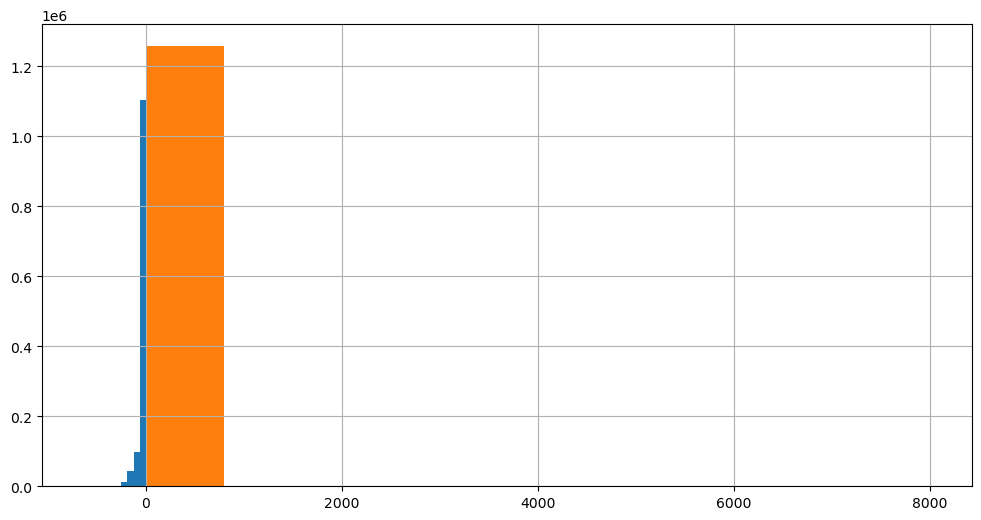

In [33]:
departures['flow'].hist(figsize=(12,6));
arrivals['flow'].hist(figsize=(12,6));

In [34]:
arrivals.nlargest(20, 'flow')

,timestamp,flow
2084055,2018-08-04 23:25:00+00:00,7999
2098359,2018-08-14 21:50:00+00:00,7999
2107004,2018-08-20 21:56:00+00:00,7999
2107005,2018-08-20 21:57:00+00:00,7999
2107009,2018-08-20 22:01:00+00:00,7999
2107010,2018-08-20 22:02:00+00:00,7999
2107023,2018-08-20 22:15:00+00:00,3148
2101589,2018-08-17 03:41:00+00:00,3042
1531827,2017-07-16 20:39:00+00:00,2755
2091430,2018-08-10 02:21:00+00:00,2629


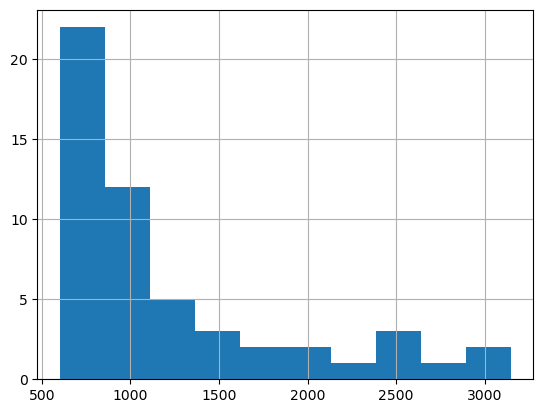

In [37]:
arrivals.loc[arrivals['flow'].between(600, 3500), 'flow'].hist();

<Axes: xlabel='timestamp'>

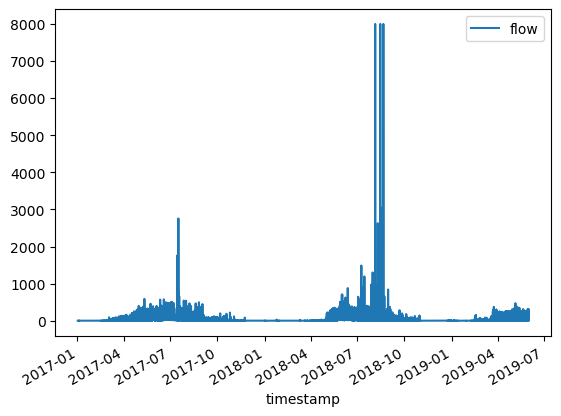

In [39]:
arrivals.plot(kind='line', x='timestamp', y='flow')

In [40]:
import numpy as np
from sklearn.mixture import GaussianMixture

def exclude_outliers(df):
    log_transform = np.log1p(df["flow"].abs())
    gmm = GaussianMixture(n_components=2, random_state=123)
    gmm.fit(log_transform.to_frame())
    means = gmm.means_.flatten()
    stds = (gmm.covariances_**0.5).flatten()
    mode1cutoff = means[0]+3*stds[0]
    mode2cutoff = means[1]+3*stds[1]
    cutoff_indexes = log_transform.loc[(log_transform > mode1cutoff)&log_transform > mode2cutoff].index
    
    return df.drop(cutoff_indexes)

In [41]:
for df in arrivals, departures:
    df = exclude_outliers(df)

# Humidity

In [43]:
humidity['humidity'].describe() # humidity should not be negative

count    1749.000000
mean       83.987816
std        26.501959
min      -100.000000
25%        79.330000
50%        91.070000
75%        96.610000
max       100.000000
Name: humidity, dtype: float64

<Axes: xlabel='timestamp'>

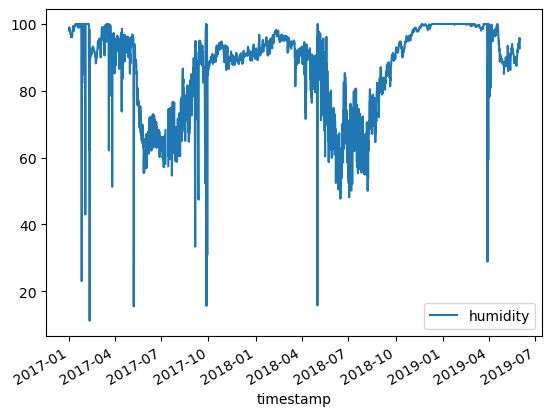

In [44]:
humidity2 = humidity.copy()
humidity2['humidity'] = humidity2['humidity'].abs()
humidity2.plot(kind='line', x='timestamp', y='humidity')

In [45]:
humidity['humidity'] = humidity['humidity'].abs()

In [46]:
humidity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  1761 non-null   datetime64[ns]
 1   humidity   1749 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 27.6 KB


In [47]:
(humidity['timestamp'] - humidity['timestamp'].shift(1)).value_counts()

timestamp
0 days 12:00:00    1755
0 days 13:00:00       3
0 days 11:00:00       2
Name: count, dtype: int64

In [56]:
# humidity['timestamp'].dt.tz_localize("Europe/Berlin", ambiguous='infer')
# cannot infer dst status

In [58]:
humidity.loc[humidity['timestamp'].dt.strftime('%Y-%m-%d') == '2017-10-29']
humidity.loc[humidity['timestamp'].dt.strftime('%Y-%m-%d') == '2018-10-28']

,timestamp,humidity
1329,2018-10-28 02:00:00,96.52
1330,2018-10-28 13:00:00,96.55


In [60]:
pd.Series(True, index=humidity.index)

0       True
1       True
2       True
3       True
4       True
        ... 
1756    True
1757    True
1758    True
1759    True
1760    True
Length: 1761, dtype: bool

In [62]:
humidity['timestamp'] = humidity['timestamp'].dt.tz_localize("Europe/Berlin", ambiguous=pd.Series(True, index=humidity.index)).dt.tz_convert("UTC")

In [64]:
humidity.duplicated().sum()

0

In [66]:
humidity.loc[humidity['humidity'].isnull()]

,timestamp,humidity
378,2017-07-09 12:00:00+00:00,NaN
379,2017-07-10 00:00:00+00:00,NaN
380,2017-07-10 12:00:00+00:00,NaN
381,2017-07-11 00:00:00+00:00,NaN
382,2017-07-11 12:00:00+00:00,NaN
383,2017-07-12 00:00:00+00:00,NaN
384,2017-07-12 12:00:00+00:00,NaN
385,2017-07-13 00:00:00+00:00,NaN
386,2017-07-13 12:00:00+00:00,NaN
387,2017-07-14 00:00:00+00:00,NaN


# Temperature

In [69]:
temperature['timestamp'] = temperature['timestamp'].dt.tz_localize("Europe/Berlin", ambiguous="infer").dt.tz_convert("UTC")

In [71]:
temperature["temperature"].describe()

count    251398.000000
mean         22.609671
std          11.702222
min          -7.260000
25%          12.450000
50%          24.480000
75%          34.220000
max          37.530000
Name: temperature, dtype: float64

In [73]:
temperature.loc[temperature['temperature'].isna(), 'timestamp'].dt.date.value_counts()

timestamp
2017-07-10    288
2017-07-11    288
2017-07-12    288
2017-07-13    288
2019-03-09    288
2017-07-09    249
2017-07-14    153
2018-04-28    142
2018-05-16     32
2019-03-08     15
2017-01-01      1
Name: count, dtype: int64

In [75]:
temperature.duplicated().sum()

0

# Weight

In [78]:
weight['timestamp'] = weight['timestamp'].dt.tz_localize("Europe/Berlin", ambiguous=pd.Series(True, index=weight.index)).dt.tz_convert("UTC")

In [80]:
weight.duplicated().sum()

0

In [82]:
weight['weight'].describe()

count     1749.000000
mean     56807.637313
std      16926.937629
min       -172.440000
25%      49793.360000
50%      58029.270000
75%      67322.570000
max      92042.230000
Name: weight, dtype: float64

In [84]:
weight.loc[weight['weight'] < 0]

,timestamp,weight
964,2018-04-28 12:00:00+00:00,-170.61
965,2018-04-29 00:00:00+00:00,-172.44
966,2018-04-29 12:00:00+00:00,-167.10
1001,2018-05-17 00:00:00+00:00,-101.54
1061,2018-06-16 00:00:00+00:00,-157.49
1062,2018-06-16 12:00:00+00:00,-143.38
1063,2018-06-17 00:00:00+00:00,-157.63
1064,2018-06-17 12:00:00+00:00,-149.62
1065,2018-06-18 00:00:00+00:00,-162.12
1066,2018-06-18 12:00:00+00:00,-147.43


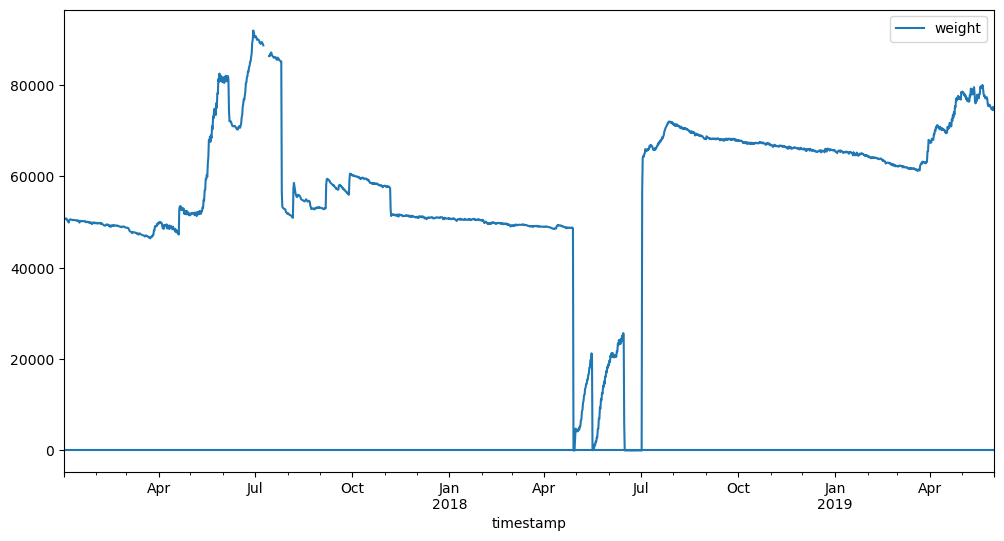

In [86]:
from matplotlib import pyplot as plt

weight.plot(kind='line', x='timestamp', y='weight', figsize=(12, 6))
plt.axhline(0)

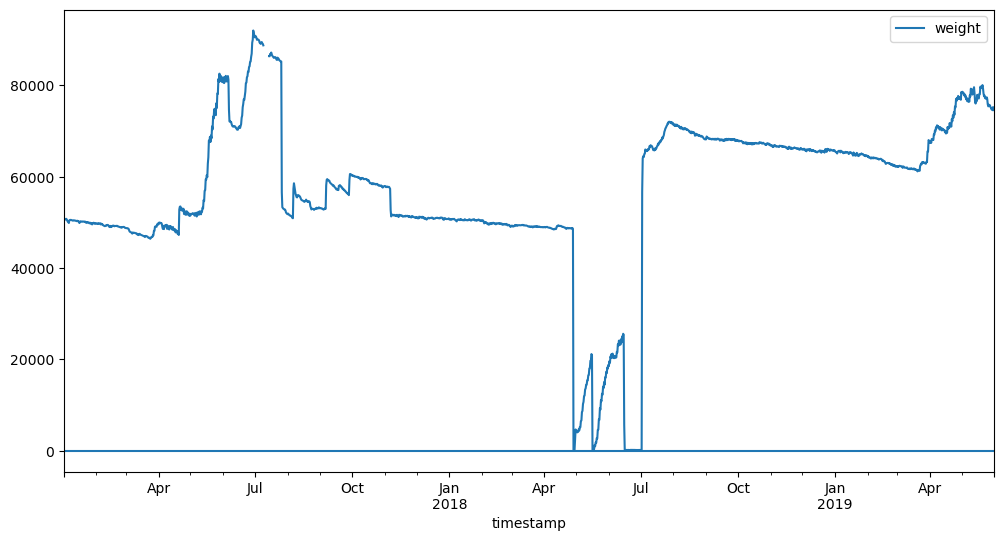

In [88]:
weight2 = weight.copy()
weight2['weight'] = weight2['weight'].abs()
weight2.plot(kind='line', x='timestamp', y='weight', figsize=(12, 6))
plt.axhline(0)

In [90]:
weight['weight'] = weight['weight'].abs()

# Reassembly and regularity

## Flow

In [94]:
flow = departures.merge(arrivals, on='timestamp', how='outer', suffixes=['_out', '_in'])
flow = flow.sort_values(by='timestamp')

In [96]:
flow

,timestamp,flow_out,flow_in
0,2017-01-01 13:15:00+00:00,0,0
1,2017-01-01 13:16:00+00:00,0,0
2,2017-01-01 13:17:00+00:00,0,0
3,2017-01-01 13:18:00+00:00,0,0
4,2017-01-01 13:19:00+00:00,0,0
...,...,...,...
1256913,2019-05-31 12:11:00+00:00,-241,128
1256914,2019-05-31 12:12:00+00:00,-226,140
1256915,2019-05-31 12:13:00+00:00,-208,144
1256916,2019-05-31 12:14:00+00:00,-217,146


In [98]:
(flow['timestamp'] - flow['timestamp'].shift(1)).value_counts()

timestamp
0 days 00:01:00    1256857
0 days 00:02:00         56
5 days 09:32:00          1
0 days 11:56:00          1
0 days 02:44:00          1
1 days 01:19:00          1
Name: count, dtype: int64

In [100]:
start_dt = flow['timestamp'].min()
end_dt = flow['timestamp'].max()
one_minute_index = pd.Series(
    pd.date_range(start=start_dt, end=end_dt, freq='1min'),
    name='timestamp'
)
one_minute_index

0         2017-01-01 13:15:00+00:00
1         2017-01-01 13:16:00+00:00
2         2017-01-01 13:17:00+00:00
3         2017-01-01 13:18:00+00:00
4         2017-01-01 13:19:00+00:00
                     ...           
1267136   2019-05-31 12:11:00+00:00
1267137   2019-05-31 12:12:00+00:00
1267138   2019-05-31 12:13:00+00:00
1267139   2019-05-31 12:14:00+00:00
1267140   2019-05-31 12:15:00+00:00
Name: timestamp, Length: 1267141, dtype: datetime64[ns, UTC]

In [102]:
flow = flow.merge(one_minute_index, on='timestamp', how='right')

## Humidity

In [105]:
(humidity['timestamp'] - humidity['timestamp'].shift(1)).value_counts()
# already perfectly regular

timestamp
0 days 12:00:00    1760
Name: count, dtype: int64

## Temperature

In [108]:
(temperature['timestamp'] - temperature['timestamp'].shift(1)).value_counts()
# already perfectly regular

timestamp
0 days 00:05:00    253429
Name: count, dtype: int64

## Weight

In [111]:
(weight['timestamp'] - weight['timestamp'].shift(1)).value_counts()
# already perfectly regular

timestamp
0 days 12:00:00    1760
Name: count, dtype: int64

# Data writes

In [116]:
sink = root_dir+'silver/'

flow.to_parquet(f'{sink}flow/schwartau__{pd.Timestamp.now().strftime("%Y-%m-%dT%Hh%Mm%Ss")}.parquet', index=False)
humidity.to_parquet(f'{sink}humidity/schwartau__{pd.Timestamp.now().strftime("%Y-%m-%dT%Hh%Mm%Ss")}.parquet', index=False)
temperature.to_parquet(f'{sink}temperature/schwartau__{pd.Timestamp.now().strftime("%Y-%m-%dT%Hh%Mm%Ss")}.parquet', index=False)
weight.to_parquet(f'{sink}weight/schwartau__{pd.Timestamp.now().strftime("%Y-%m-%dT%Hh%Mm%Ss")}.parquet', index=False)